In [3]:
###################
# Library imports #
###################

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from joblib import Parallel, delayed, dump

from scipy.integrate import quad

from tenpy.networks.mps import MPS
from tenpy.models.model import CouplingMPOModel
from tenpy.networks import site
from tenpy.algorithms.dmrg import TwoSiteDMRGEngine
from tenpy.algorithms import tdvp

In [4]:
################################################################
# Define the time-dependent spinless interacting fermion model #
################################################################

class time_dependent_Hubbard(CouplingMPOModel):

    default_lattice = 'Ladder' # Using ladder to represent sample + probe
    force_default_lattice = True # Ensure we always use the ladder lattice

    def init_sites(self, model_params): 
        fermion_sample = site.SpinHalfFermionSite(cons_N='N', cons_Sz='Sz') # Sample site
        fermion_probe = site.SpinHalfFermionSite(cons_N='N', cons_Sz='Sz') # Probe site
        site.set_common_charges([fermion_sample, fermion_probe], new_charges='same') # Independent charges
        return [fermion_sample, fermion_probe] # Return list of site objects

    def init_terms(self, model_params):

        # Extract parameters
        J = model_params.get('J', 1.0)
        U = model_params.get('U', 10.0)
        V = model_params.get('V', 5.0)

        g = model_params.get('g', 0.2)
        omega = model_params.get('omega', 1.0)

        mu = model_params.get('mu', 0.0)
 
        # Hopping within the sample
        self.add_coupling(-J, 0, 'Cdu', 0, 'Cu', [1], plus_hc=True)
        self.add_coupling(-J, 0, 'Cdd', 0, 'Cd', [1], plus_hc=True)

        # Onsite interaction in the sample
        self.add_onsite(U, 0, 'NuNd')

        # Neighbor interaction within the sample
        self.add_coupling(V, 0, 'Ntot', 0, 'Ntot', [1], plus_hc=False)

        # Chemical potential on the sample
        self.add_onsite(mu, 0, 'Ntot')

        # Probe energy term
        self.add_onsite(omega, 1, 'Ntot')

        # Interaction between sample and probe
        self.add_coupling(g, 0, 'Cdu', 1, 'Cu', [0], plus_hc=True)
        self.add_coupling(g, 0, 'Cdd', 1, 'Cd', [0], plus_hc=True)

#############
# Functions #
#############

def d_occ(psi, model):

    probe_sites = model.lat.mps_idx_fix_u(1) # Probe sites
    NuNd = psi.correlation_function('Nu', 'Nd', sites1=probe_sites, sites2=probe_sites) # Compute correlation function on probe
    
    Nu = psi.expectation_value('Nu', sites=probe_sites) # Compute correlation function on probe
    Nd = psi.expectation_value('Nd', sites=probe_sites)

    C_ij = NuNd  
    NN_ij = np.outer(Nu, Nd)
    return C_ij, NN_ij

def dmrg_ground_state(psi_init, model, dmrg_params):

    dmrg_engine = TwoSiteDMRGEngine(psi_init, model, dmrg_params) # Initialize DMRG engine
    E0, psi_gs = dmrg_engine.run() # Run DMRG to find ground state

    return E0, psi_gs

##################################################################################################
# Main function that runs TDVP for a given omega and returns the correlation functions over time #
##################################################################################################

def simulation(times, omega_val, A, Probe, psi_init, model_parameter, tdvp_params):

    model_params_copy = model_parameter.copy()  # Create a copy to avoid modifying the original

    J0 = model_params_copy.get('J', 1.0)    
    L = model_params_copy['L']
    N_t = len(times)

    C_t_ij = np.zeros((N_t, L, L), dtype=complex)
    NN_t_ij = np.zeros((N_t, L, L), dtype=complex)

    psi = psi_init.copy()

    for ti, _ in enumerate(times):

        model_params_copy['J'] = J0 * np.exp(1j * A[ti])
    
        model_params_copy['omega'] = omega_val
    
        model_params_copy['g'] = Probe[ti]
    
        model = time_dependent_Hubbard(model_params_copy)
    
        eng_tdvp = tdvp.TwoSiteTDVPEngine(psi, model, tdvp_params)
    
        eng_tdvp.run()

        psi = eng_tdvp.psi

        C_t_ij[ti, :, :], NN_t_ij = d_occ(psi, model) 
    
    return C_t_ij, NN_t_ij

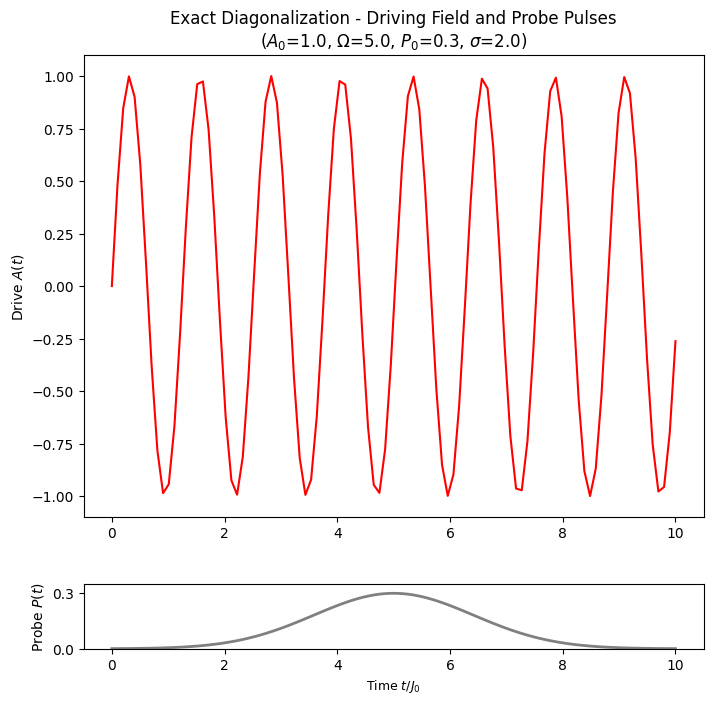

In [15]:
########
# Time #
########

N_t = 100
times = np.linspace(0.0, 10.0, N_t)
dt = times[1]-times[0]

#########################################################################
# Processing Energy scan array to submit different simultaneously tasks #
#########################################################################

N_omega = 30 

omega_scan = np.linspace(-10.0, 10.0, N_omega) 

###################
# Model Paramaters#
###################

L = 32

J0 = 1.0
U0 = 5.0
V0 = 0.0
mu = - U0 

########################
# init Drive and Pulse #
########################

A0 = 1.0
omega_drive = 5.0

P0 = 0.3
t_probe = 5.0
sigma = 2.0

A = A0 * np.sin(omega_drive * times)

Probe = P0 * np.exp(-(times - t_probe)**2 / (sigma**2))

#######################################
# DMRG, TDVP and model parameter dict #
#######################################

dmrg_params = {
    'mixer': True,
    'max_E_err': 1.e-6,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-6,
    },
}

tdvp_params = {
    'N_steps': 1,
    'dt': dt,
    'trunc_params': {
        'chi_max': 100, 
        'svd_min': 1.e-6,
    },
}

plt.figure(figsize=(8, 6))
ax_main = plt.gca()

plt.plot(times, A, color='red', label=r'$A(t)$')
 
plt.ylabel(r'Drive $A(t)$')
plt.title(r'Exact Diagonalization - Driving Field and Probe Pulses' + '\n' + r'($A_0$={:.5}, $\Omega$={:.1f}, $P_0$={:.1f}, $\sigma$={:.3})'.format(A0, omega_drive, P0, sigma))

# Add inset axes at the bottom showing only the probe pulse
ax_inset = inset_axes(ax_main, width="100%", height="40%", loc='lower center',
                       bbox_to_anchor=(0.0, -0.3, 1.0, 0.35), 
                       bbox_transform=ax_main.transAxes)

ax_inset.plot(times, Probe, color='gray', linewidth=2)
ax_inset.set_xlabel(r'Time $t/J_0$', fontsize=9)
ax_inset.set_ylabel(r'Probe $P(t)$')
ax_inset.set_ylim(0.0, 0.35)
ax_inset.set_yticks([0.0, 0.3])
plt.show()

In [16]:
#################################
# Bookkeeping: print statements #
#################################

print("Model parameters: J0={}, U0={}, V0={}".format(J0, U0, V0))
print()
print("Drive and Probe: A0={}, omega={}, P0={}, sigma={}".format(A0, omega_drive, P0, sigma))
print()
print("Resolution parameters: N_t={}, N_k={}, N_omega={}".format(N_t, L+1, N_omega))
print()
print("===================================================================================")
print()
print("-> Scanning lower band...")
print()

mu_probe = 10.0**4

s_filling = 1.0 
p_filling = 0.0

Ns = int(s_filling * L / 2)
Np = int(p_filling * L / 2)

model_parameter = {
    'L': L,
    'J': J0,
    'g': 0.0,
    'V': V0,
    'omega': mu_probe,
    'mu':mu,
    'bc_MPS': 'finite',
    }

model_init = time_dependent_Hubbard(model_parameter)

lattice = model_init.lat

product_state = [
    (f_s, f_p) for f_s, f_p in zip(['up', 'down'] * Ns + ['empty'] * (L - Ns), ['full'] * Np + ['empty'] * (L - 2 * Np))
    ]

psi_init = MPS.from_lat_product_state(lattice, product_state)

E0, psi_gs = dmrg_ground_state(psi_init, model_init, dmrg_params)

sample_occupation = psi_gs.expectation_value('Ntot', sites=lattice.mps_idx_fix_u(0)) 
probe_occupation = psi_gs.expectation_value('Ntot', sites=lattice.mps_idx_fix_u(1))

print(r'Sample occupation before time-evolution: {:.5}'.format(np.mean(sample_occupation)))
print(r'Probe occupation before time-evolution: {:.5}'.format(np.mean(probe_occupation)))
print()

results_low = Parallel(n_jobs=-1, verbose=10)(delayed(simulation)(times, w_val, A, Probe, psi_gs, model_parameter, tdvp_params) for w_val in omega_scan)

print()
print("Simulation completed! Saving array ...")

D_l, NN_l = zip(*results_low)

D_l = np.array(D_l)
NN_l = np.array(NN_l)

print()
print("===================================================================================")
print()
print("-> Scanning upper band...")
print()

mu_probe = -10.0**4

s_filling = 1.0 
p_filling = 1.0

Ns = int(s_filling * L / 2)
Np = int(p_filling * L / 2)

model_parameter = {
    'L': L,
    'J': J0,
    'g': 0.0,
    'V': V0,
    'omega': mu_probe,
    'mu':mu,
    'bc_MPS': 'finite',
    }

model_init = time_dependent_Hubbard(model_parameter)

lattice = model_init.lat

product_state = [
    (f_s, f_p) for f_s, f_p in zip(['up', 'down'] * Ns + ['empty'] * (L - Ns), ['full'] * Np + ['empty'] * (L - 2 * Np))
    ]

psi_init = MPS.from_lat_product_state(lattice, product_state)

E0, psi_gs = dmrg_ground_state(psi_init, model_init, dmrg_params)

sample_occupation = psi_gs.expectation_value('Ntot', sites=lattice.mps_idx_fix_u(0)) 
probe_occupation = psi_gs.expectation_value('Ntot', sites=lattice.mps_idx_fix_u(1))

print(r'Sample occupation before time-evolution: {:.5}'.format(np.mean(sample_occupation)))
print(r'Probe occupation before time-evolution: {:.5}'.format(np.mean(probe_occupation)))
print()

results_up = Parallel(n_jobs=-1, verbose=10)(delayed(simulation)(times, w_val, A, Probe, psi_gs, model_parameter, tdvp_params) for w_val in omega_scan)

D_u, NN_u = zip(*results_up)

D_u = np.array(D_u)
NN_u = np.array(NN_u)

print()
print("Simulation completed! Saving array...")



Model parameters: J0=1.0, U0=5.0, V0=0.0

Drive and Probe: A0=1.0, omega=5.0, P0=0.3, sigma=2.0

Resolution parameters: N_t=100, N_k=33, N_omega=30


-> Scanning lower band...

Sample occupation before time-evolution: 1.0
Probe occupation before time-evolution: 7.1157e-18



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed: 32.8min remaining: 294.9min
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed: 33.4min remaining: 109.6min
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed: 33.7min remaining: 58.3min
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed: 34.1min remaining: 34.1min
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed: 34.6min remaining: 20.0min
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed: 35.9min remaining: 10.9min
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed: 36.4min remaining:  4.0min
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 37.3min finished



Simulation completed! Saving array ...


-> Scanning upper band...

Sample occupation before time-evolution: 1.0
Probe occupation before time-evolution: 2.0



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 30 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  30 | elapsed: 33.0min remaining: 297.1min
[Parallel(n_jobs=-1)]: Done   7 out of  30 | elapsed: 34.1min remaining: 112.0min
[Parallel(n_jobs=-1)]: Done  11 out of  30 | elapsed: 34.8min remaining: 60.1min
[Parallel(n_jobs=-1)]: Done  15 out of  30 | elapsed: 35.3min remaining: 35.3min
[Parallel(n_jobs=-1)]: Done  19 out of  30 | elapsed: 35.5min remaining: 20.6min
[Parallel(n_jobs=-1)]: Done  23 out of  30 | elapsed: 35.8min remaining: 10.9min
[Parallel(n_jobs=-1)]: Done  27 out of  30 | elapsed: 36.3min remaining:  4.0min



Simulation completed! Saving array...


[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 36.6min finished


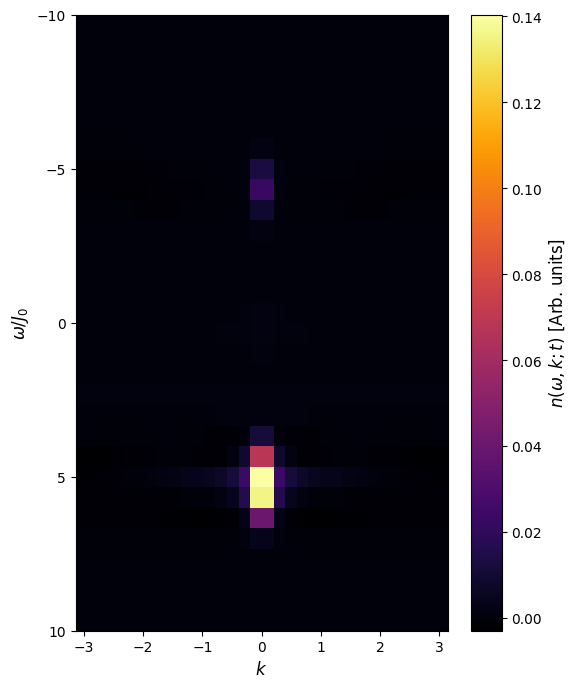

In [47]:
d_k_low = np.zeros((N_omega, N_t, L), dtype=float)
d_k_up = np.zeros((N_omega, N_t, L), dtype=float)

k = np.linspace(-np.pi, np.pi, L)
l = np.arange(L)
phase_factor = np.exp(-1j * np.outer(k, l)) / np.sqrt(L)

for wi in range(N_omega):
    for ti in range(N_t):
        d_k_low[wi, ti, :] = np.real(
            np.diag(phase_factor @ (D_l[wi, ti, :, :])@ phase_factor.conj().T)
        )
        d_k_up[wi, ti, :] = 2-np.real(
             np.diag(phase_factor @ (D_u[wi, ti, :, :]) @ phase_factor.conj().T)
         )

d_k = d_k_low #+ d_k_up

#n_k /= np.max(n_k[:, -1, :])

plt.figure(figsize=(6, 8))
plt.imshow(
    d_k[:, -1, :],
    extent=[k[0], k[-1], omega_scan[-1], omega_scan[0]],
    aspect='auto',
    cmap='inferno',
    origin='lower',
    vmin=np.min(d_k[:, -1, :]),
    vmax=np.max(d_k[:, -1, :])
)

# Import bessel function for non-interacting dispersion
from scipy.special import jn

J_eff = J0 * jn(0, E0/omega_drive)

#plt.plot(k, -2*J_eff*np.cos(k), color='gray', alpha=0.5, linestyle='--', label=r'$-2J_0 J_0(A_0) \cos(k)$')

cbar = plt.colorbar(label=r'$n(\omega, k; t)$ [Arb. units]')
cbar.set_label(r'$n(\omega, k; t)$ [Arb. units]', fontsize=12)
plt.xlabel(r'$k$', fontsize=12)
plt.ylabel(r'$\omega / J_0$', fontsize=12)
plt.yticks([-10.0, -5.0, 0.0, 5.0, 10.0])

plt.show()

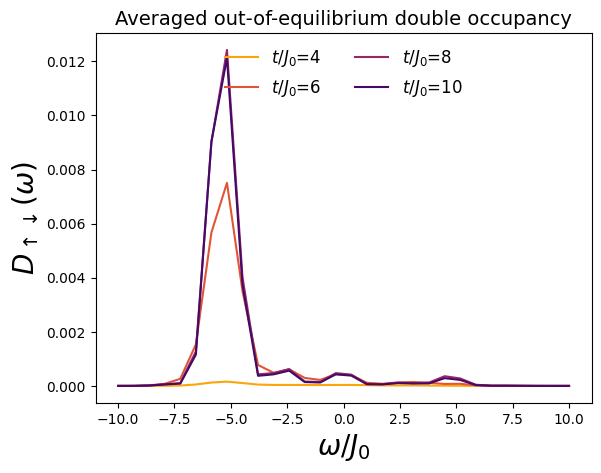

In [42]:
d_k_avg = np.sum(d_k[:, :, :], axis=2) / len(k) 

t_peaks = [4.0, 6.0, 8.0, 10.0]

for t_idx in t_peaks:
    ti = np.argmin(np.abs(times - t_idx))
    plt.plot(omega_scan, d_k_avg[:, ti].T, color=plt.cm.inferno(1.2-ti / N_t), label=r'$t /J_0$={:.0f}'.format(times[ti]))
    plt.xlabel(r'$\omega / J_0$', fontsize=20)
    plt.ylabel(r'$D_{\uparrow\downarrow}(\omega)$', fontsize=20)
    plt.title(f'Averaged out-of-equilibrium double occupancy', fontsize=14)
    #plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
    #plt.ylim(0.0, 0.009)
    plt.legend(loc='upper center', ncol=2, fontsize=12, frameon=False)